In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score
)

df = pd.read_csv("../data/raw/creditcard.csv")

X = df.drop(columns=["Class"])
y = df["Class"]

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    stratify=y,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

scaler = StandardScaler()

X_train[["Time", "Amount"]] = scaler.fit_transform(
    X_train[["Time", "Amount"]]
)

X_val[["Time", "Amount"]] = scaler.transform(
    X_val[["Time", "Amount"]]
)

X_test[["Time", "Amount"]] = scaler.transform(
    X_test[["Time", "Amount"]]
)

In [2]:
model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

model.fit(X_train, y_train)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default 

In [3]:
y_val_pred = model.predict(X_val)
y_val_prob = model.predict_proba(X_val)[:, 1]

In [4]:
print("=== Classification Report ===")
print(classification_report(y_val, y_val_pred))

print("=== Confusion Matrix ===")
print(confusion_matrix(y_val, y_val_pred))

print("ROC-AUC:", roc_auc_score(y_val, y_val_prob))
print("PR-AUC:", average_precision_score(y_val, y_val_prob))

=== Classification Report ===
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     42647
           1       0.07      0.88      0.12        74

    accuracy                           0.98     42721
   macro avg       0.53      0.93      0.56     42721
weighted avg       1.00      0.98      0.99     42721

=== Confusion Matrix ===
[[41742   905]
 [    9    65]]
ROC-AUC: 0.9684146535449089
PR-AUC: 0.6275251631550335


In [5]:
from xgboost import XGBClassifier

ModuleNotFoundError: No module named 'xgboost'

In [6]:
pip install xgboost

Defaulting to user installation because normal site-packages is not writeable
  Using cached xgboost-3.4.1-py3-none-win_amd64.whl.metadata (2.0 kB)
Using cached xgboost-3.4.1-py3-none-win_amd64.whl (48.9 MB)
Note: you may need to restart the kernel to use updated packages.


In [7]:
from xgboost import XGBClassifier

In [8]:
negative = (y_train == 0).sum()
positive = (y_train == 1).sum()

scale_pos_weight = negative / positive

print("Negative:", negative)
print("Positive:", positive)
print("scale_pos_weight:", scale_pos_weight)

Negative: 199020
Positive: 344
scale_pos_weight: 578.546511627907


In [9]:
xgb_model = XGBClassifier(
    n_estimators=500,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    objective="binary:logistic",
    eval_metric="aucpr",
    tree_method="hist",
    random_state=42,
    n_jobs=-1,
    early_stopping_rounds=50
)

xgb_model.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",50
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'aucpr'
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [10]:
y_val_pred_xgb = xgb_model.predict(X_val)
y_val_prob_xgb = xgb_model.predict_proba(X_val)[:, 1]

In [11]:
print("=== XGBoost Classification Report ===")
print(classification_report(y_val, y_val_pred_xgb))

print("=== XGBoost Confusion Matrix ===")
print(confusion_matrix(y_val, y_val_pred_xgb))

print("ROC-AUC:", roc_auc_score(y_val, y_val_prob_xgb))
print("PR-AUC:", average_precision_score(y_val, y_val_prob_xgb))

=== XGBoost Classification Report ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     42647
           1       0.89      0.77      0.83        74

    accuracy                           1.00     42721
   macro avg       0.95      0.89      0.91     42721
weighted avg       1.00      1.00      1.00     42721

=== XGBoost Confusion Matrix ===
[[42640     7]
 [   17    57]]
ROC-AUC: 0.9826023059193036
PR-AUC: 0.8413674114766542


In [12]:
xgb_model.predict(X_val)

array([0, 0, 0, ..., 0, 0, 0], shape=(42721,))

In [13]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    precision_recall_curve
)

precision, recall, thresholds = precision_recall_curve(
    y_val,
    y_val_prob_xgb
)

f1 = (
    2 * precision[:-1] * recall[:-1]
    / (precision[:-1] + recall[:-1] + 1e-10)
)

best_idx = np.argmax(f1)

print("Best F1 threshold:", thresholds[best_idx])
print("Precision:", precision[best_idx])
print("Recall:", recall[best_idx])
print("F1:", f1[best_idx])

Best F1 threshold: 0.9264692
Precision: 0.9655172413793104
Recall: 0.7567567567567568
F1: 0.8484848484355831


In [14]:
threshold_results = []

for threshold in np.arange(0.10, 0.91, 0.05):
    predictions = (y_val_prob_xgb >= threshold).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(y_val, predictions, zero_division=0),
        "Recall": recall_score(y_val, predictions, zero_division=0),
        "F1": f1_score(y_val, predictions, zero_division=0)
    })

threshold_df = pd.DataFrame(threshold_results)

display(threshold_df.round(3))

,Threshold,Precision,Recall,F1
0,0.10,0.756,0.838,0.795
1,0.15,0.800,0.811,0.805
2,0.20,0.806,0.784,0.795
3,0.25,0.866,0.784,0.823
4,0.30,0.879,0.784,0.829
5,0.35,0.879,0.784,0.829
6,0.40,0.892,0.784,0.835
7,0.45,0.892,0.784,0.835
8,0.50,0.891,0.770,0.826
9,0.55,0.891,0.770,0.826


In [15]:
plt.figure(figsize=(10, 6))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1"],
    marker="o",
    label="F1"
)

plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.title("Precision–Recall–F1 vs Classification Threshold")
plt.legend()
plt.grid(True)
plt.show()

NameError: name 'plt' is not defined

In [16]:
import matplotlib.pyplot as plt

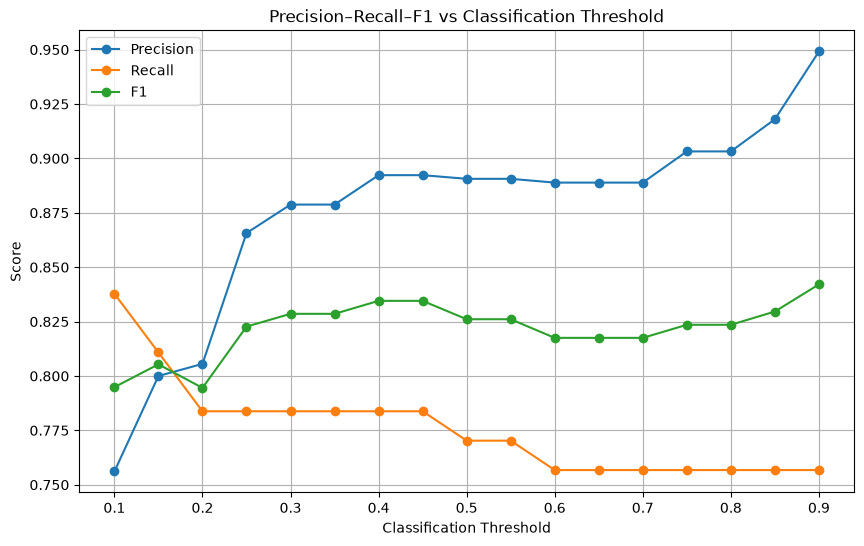

In [17]:
plt.figure(figsize=(10, 6))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1"],
    marker="o",
    label="F1"
)

plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.title("Precision–Recall–F1 vs Classification Threshold")
plt.legend()
plt.grid(True)
plt.show()

In [18]:
best_idx = np.argmax(f1)

print("Exact best threshold:", thresholds[best_idx])
print("Precision:", precision[best_idx])
print("Recall:", recall[best_idx])
print("F1:", f1[best_idx])

Exact best threshold: 0.9264692
Precision: 0.9655172413793104
Recall: 0.7567567567567568
F1: 0.8484848484355831


In [19]:
# Final threshold selected from validation set
final_threshold = thresholds[best_idx]

# Test-set probabilities
y_test_prob = xgb_model.predict_proba(X_test)[:, 1]

# Apply the validation-selected threshold
y_test_pred = (y_test_prob >= final_threshold).astype(int)

In [20]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score
)

print("=== FINAL TEST CLASSIFICATION REPORT ===")
print(
    classification_report(
        y_test,
        y_test_pred,
        digits=4
    )
)

print("=== CONFUSION MATRIX ===")
print(confusion_matrix(y_test, y_test_pred))

print("\n=== TEST ROC-AUC ===")
print(roc_auc_score(y_test, y_test_prob))

print("\n=== TEST PR-AUC ===")
print(average_precision_score(y_test, y_test_prob))

=== FINAL TEST CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

           0     0.9996    0.9999    0.9998     42648
           1     0.9508    0.7838    0.8593        74

    accuracy                         0.9996     42722
   macro avg     0.9752    0.8919    0.9295     42722
weighted avg     0.9995    0.9996    0.9995     42722

=== CONFUSION MATRIX ===
[[42645     3]
 [   16    58]]

=== TEST ROC-AUC ===
0.968441852094075

=== TEST PR-AUC ===
0.8435582516543956


In [21]:
from sklearn.metrics import precision_score, recall_score, f1_score

print("Fraud Precision:", precision_score(y_test, y_test_pred))
print("Fraud Recall:", recall_score(y_test, y_test_pred))
print("Fraud F1:", f1_score(y_test, y_test_pred))

Fraud Precision: 0.9508196721311475
Fraud Recall: 0.7837837837837838
Fraud F1: 0.8592592592592593


=== FINAL TEST CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

           0     0.9996    0.9999    0.9998     42648
           1     0.9508    0.7838    0.8593        74

    accuracy                         0.9996     42722
   macro avg     0.9752    0.8919    0.9295     42722
weighted avg     0.9995    0.9996    0.9995     42722

=== CONFUSION MATRIX ===
[[42645     3]
 [   16    58]]

=== TEST ROC-AUC ===
0.968441852094075

=== TEST PR-AUC ===
0.8435582516543956

=== FRAUD METRICS ===
Precision: 0.9508196721311475
Recall: 0.7837837837837838
F1: 0.8592592592592593


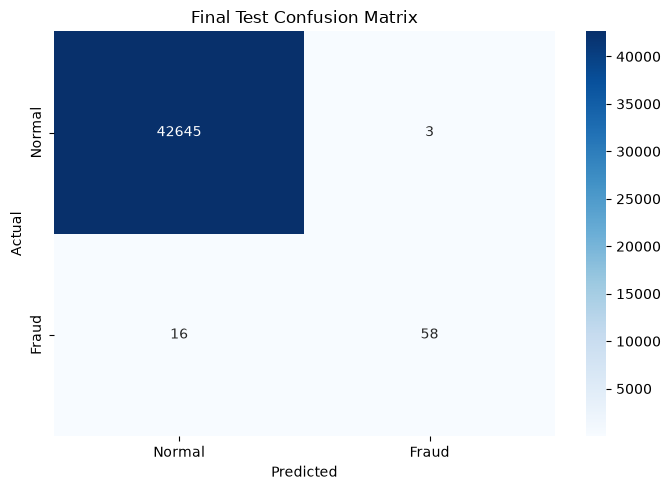

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score
)

# Use the threshold selected from validation
final_threshold = 0.9264692

# Test probabilities
y_test_prob = xgb_model.predict_proba(X_test)[:, 1]

# Final predictions
y_test_pred = (y_test_prob >= final_threshold).astype(int)

# -----------------------------
# Final test metrics
# -----------------------------
print("=== FINAL TEST CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_test_pred, digits=4))

print("=== CONFUSION MATRIX ===")
cm = confusion_matrix(y_test, y_test_pred)
print(cm)

print("\n=== TEST ROC-AUC ===")
print(roc_auc_score(y_test, y_test_prob))

print("\n=== TEST PR-AUC ===")
print(average_precision_score(y_test, y_test_prob))

print("\n=== FRAUD METRICS ===")
print("Precision:", precision_score(y_test, y_test_pred))
print("Recall:", recall_score(y_test, y_test_pred))
print("F1:", f1_score(y_test, y_test_pred))

# -----------------------------
# Confusion matrix plot
# -----------------------------
plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal", "Fraud"],
    yticklabels=["Normal", "Fraud"]
)

plt.title("Final Test Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()